In [26]:
from atomica.models import MultiClassClassifierModel, MultiLabelClassifierModel, ResidueClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset, LabelledPDBDataset
from atomica.trainers import Trainer

from multiclass_metrics import compute_multiclass_metrics
from multilabel_metrics import compute_multilabel_metrics

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from glob import glob

sns.set_context("notebook")
custom_colors = ['#B0B0B0', '#B0B0B0', '#B0B0B0', '#B0B0B0', '#00C4C7', '#059094']
xtick_map = {
    'RNAGlib': 'RNAGlib',
    'rinalmo': 'RiNALMo',
    'rnafm': 'RNA-FM',
    'rnaernie': 'RNAErnie',
    'atomica': 'ATOMICA',
    'atomica-ensemble': 'ATOMICA\nEnsemble'
}

DATA_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks"
MODEL_DIR="/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark"

In [2]:
def process_atomica_rnafm_mlp_results(results_dir: str, val_metric: str, exclude_dropout: bool = False) -> pd.DataFrame:
    results = []
    for version in os.listdir(results_dir):
        if not version.startswith("version_"):
            continue
        for seed in os.listdir(os.path.join(results_dir, version)):
            if not seed.startswith("seed_"):
                continue
            if exclude_dropout and "dropout" in version:
                dropout_idx = version.split("_").index("dropout") + 1
                dropout_val = float(version.split("_")[dropout_idx])
                if dropout_val > 0:
                    continue
            if not os.path.exists(os.path.join(results_dir, version, seed, "training_history.json")):
                continue
            with open(os.path.join(results_dir, version, seed, "training_history.json"), "r") as f:
                training_history = json.load(f)
            val_metric_value = training_history[val_metric]
            results.append({
                "version": version,
                "seed": seed,
                "val_metric": val_metric_value,
            })
    df = pd.DataFrame(results)
    ave_df = df.groupby('version')[['val_metric']].mean()
    ave_df.sort_values(by='val_metric', ascending=False, inplace=True)
    
    test_results = []
    best_version = ave_df.index[0]
    for seed in os.listdir(os.path.join(results_dir, best_version)):
        test_metrics_path = os.path.join(results_dir, best_version, seed, "test_metrics.json")
        with open(test_metrics_path, "r") as f:
            test_metrics = json.load(f)
        test_metrics['version'] = best_version
        test_metrics['seed'] = seed
        test_metrics['checkpoint_path'] = os.path.join(results_dir, best_version, seed)
        test_results.append(test_metrics)
    return pd.DataFrame(test_results)

def get_model(model_checkpoint: str, task_name: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    if task_name == "RNAGo":
        return MultiLabelClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Ligand":
        return MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Protein" or task_name == "RNA_Site":
        return ResidueClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    else:
        raise ValueError(f"Task name {task_name} not supported")

def get_atomica_results(model_checkpoint, task_name, split="val", threshold=0.5, sample_blocks=False):
    if os.path.exists(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet")) and not sample_blocks:
        return pd.read_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    if sample_blocks:
        dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet",
                        random_block_sampling=True,
                        p_keep=0.9,
                        p_none=0.2,
                    )
    else:
        dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    model = get_model(model_checkpoint, task_name)

    model.eval()
    model.to("cuda")
    batch_size = 1

    num_runs = 10 if sample_blocks else 1
    atomica_preds = []
    for run_idx in tqdm(range(num_runs), total=num_runs, desc="Running multiple runs for inference"):
        atomica_preds_run = []
        for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc="Running inference"):
            with torch.no_grad():
                batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
                batch = MultiClassLabelledPDBDataset.collate_fn(batch)
                batch = Trainer.to_device(batch, "cuda")
                atomica_preds_run.append(model.infer(batch).cpu().numpy())
        atomica_preds.append(np.concatenate(atomica_preds_run))
    atomica_preds = np.stack(atomica_preds, axis=0)
    print(atomica_preds[:, 0,0])
    atomica_preds = atomica_preds.mean(axis=0)
    
    if task_name == "RNA_Protein":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_ids = sum([[x['id']] * len(x['label']) for x in dataset.data], [])
        atomica_preds = atomica_preds.flatten()
    elif task_name == "RNA_Site":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_preds = atomica_preds.flatten()
        atomica_ids = []
        for x in dataset.data:
            assert len(x['label']) == len(x['block_to_pdb_indexes'])
            for _, pdb_index in sorted(x['block_to_pdb_indexes'].items()):
                atomica_ids.append(x['id'] + '_' + str(pdb_index))
    else:
        atomica_labels = np.array([x['label'] for x in dataset.data])
        atomica_ids = np.array([x['id'] for x in dataset.data])
        atomica_labels = list(atomica_labels)
        atomica_preds = list(atomica_preds)
    atomica_results = pd.DataFrame({
        'id': atomica_ids,
        'label': atomica_labels,
        'pred_probability': atomica_preds,
    })
    if task_name == "RNA_Ligand":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: np.argmax(x))
    elif task_name == "RNAGo":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: (x > threshold).astype(int))
    else:
        atomica_results['pred'] = (atomica_results['pred_probability'] > threshold).astype(int)

    atomica_results.to_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    return atomica_results

In [3]:
def load_rnaglib_baseline(fname):
    with open(fname, "r") as f:
        lines = f.readlines()
    lines = [line.strip()[len("Test metrics: "):] for line in lines if line.startswith("Test metrics: ")]
    metrics = [ast.literal_eval(line) for line in lines]
    return pd.DataFrame(metrics)

rnaglib_baselines = {}
for i, task_name in enumerate(["RNA_Ligand","RNA_Site","RNA_Protein","RNAGo"]):
    fname = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/job_status/train_rnaglib_baselines.*.54939697_{i}.out")
    df = load_rnaglib_baseline(fname[0])
    df['baseline_model'] = 'RNAGlib'
    agg_method = {col: ['mean', 'std'] for col in df.columns if col != 'baseline_model'}
    df = df.groupby('baseline_model').agg(agg_method)
    print(task_name)
    display(df)
    rnaglib_baselines[task_name] = df

RNA_Ligand


accuracy      balanced_accuracy      f1_macro       f1_micro  \
                    mean  std              mean  std     mean  std      mean   
baseline_model                                                                 
RNAGlib         0.659091  0.0          0.333333  0.0  0.26484  0.0  0.659091   

                    f1_weighted           loss            
                std        mean  std      mean       std  
baseline_model                                            
RNAGlib         0.0    0.523661  0.0  0.885411  0.005164

RNA_Site


accuracy             roc_auc               auprc            \
                    mean       std      mean       std      mean       std   
baseline_model                                                               
RNAGlib         0.845964  0.007311  0.619486  0.017852  0.134982  0.010701   

                    loss            
                    mean       std  
baseline_model                      
RNAGlib         1.953686  0.144082

RNA_Protein


accuracy             roc_auc               auprc            \
                    mean       std      mean       std      mean       std   
baseline_model                                                               
RNAGlib         0.585343  0.022603  0.670051  0.007817  0.395837  0.016221   

                    loss            
                    mean       std  
baseline_model                      
RNAGlib         0.852408  0.030831

RNAGo


subset_accuracy           f1_macro            f1_micro  \
                          mean       std     mean       std      mean   
baseline_model                                                          
RNAGlib               0.528889  0.085721  0.34624  0.110099  0.322504   

                         f1_weighted                loss            
                     std        mean       std      mean       std  
baseline_model                                                      
RNAGlib         0.223185    0.294566  0.218671  0.428101  0.123239

# RNAGo
Not SOTA

In [45]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNAGo/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
baseline_agg_results

subset_accuracy            f1_macro            f1_micro  \
                          mean       std      mean       std      mean   
baseline_model                                                           
rinalmo               0.893333  0.023094  0.859179  0.011015  0.891039   
rnaernie              0.728889  0.007698  0.613292  0.025704  0.676667   
rnafm                 0.831111  0.027756  0.715697  0.009991  0.775113   

                         f1_weighted            
                     std        mean       std  
baseline_model                                  
rinalmo         0.021107    0.894595  0.023435  
rnaernie        0.021225    0.656069  0.019522  
rnafm           0.010831    0.792137  0.007553

In [46]:
# imbalanced dataset
task_name = "RNAGo"
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    labels = np.stack(df['label'])
    label_counts = np.sum(labels, axis=0)
    print(split, label_counts)

train [127.  71.  50.  50.  75.]
val [32.  3. 10. 27.  5.]
test [ 8.  7. 11.  1. 20.]


In [47]:
test_metrics = []
val_metrics = []

checkpoint_paths = [
    f"{MODEL_DIR}/RNAGo/models/version_68/checkpoint/epoch200_step25929.pt",
    f"{MODEL_DIR}/RNAGo/models/version_63/checkpoint/epoch170_step23769.pt",
    f"{MODEL_DIR}/RNAGo/models/version_60/checkpoint/epoch188_step27027.pt",
    f"{MODEL_DIR}/RNAGo/models/version_65/checkpoint/epoch282_step39337.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_62/checkpoint/epoch188_step26460.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_64/checkpoint/epoch212_step30459.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_66/checkpoint/epoch181_step21840.pt",
]

checkpoint_paths = [
    f"{MODEL_DIR}/RNAGo/models/version_79/checkpoint/epoch239_step30480.pt",
    f"{MODEL_DIR}/RNAGo/models/version_78/checkpoint/epoch266_step33909.pt",
    f"{MODEL_DIR}/RNAGo/models/version_77/checkpoint/epoch184_step23495.pt",
    f"{MODEL_DIR}/RNAGo/models/version_76/checkpoint/epoch213_step27178.pt",
]

checkpoint_paths = [
    # f"{MODEL_DIR}/RNAGo/models/version_77/checkpoint/epoch184_step23495.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_80/checkpoint/epoch273_step34798.pt",
    f"{MODEL_DIR}/RNAGo/models/version_81/checkpoint/epoch294_step37465.pt",
    f"{MODEL_DIR}/RNAGo/models/version_82/checkpoint/epoch288_step36703.pt",
    # f"{MODEL_DIR}/RNAGo/models/version_83/checkpoint/epoch242_step30861.pt",
    f"{MODEL_DIR}/RNAGo/models/version_84/checkpoint/epoch226_step28829.pt",
    f"{MODEL_DIR}/RNAGo/models/version_85/checkpoint/epoch270_step34417.pt",
    f"{MODEL_DIR}/RNAGo/models/version_86/checkpoint/epoch285_step36322.pt",
]

ensemble_test_prob = None
ensemble_val_prob = None
for checkpoint_path in checkpoint_paths:
    atomica_results_val = get_atomica_results(checkpoint_path, "RNAGo", split="val")
    atomica_results_test = get_atomica_results(checkpoint_path, "RNAGo", split="test")

    best_f1_threshold = 0.0
    best_f1_score = 0.0
    f1_thresholds = np.linspace(0.0, 0.5, 6)
    for threshold in f1_thresholds:
        metrics = compute_multilabel_metrics(
            y_true=np.stack(atomica_results_val['label']),
            y_proba=np.stack(atomica_results_val['pred_probability']),
            threshold=threshold
        )
        if metrics.f1_weighted > best_f1_score:
            best_f1_score = metrics.f1_weighted
            best_f1_threshold = threshold
    atomica_preds = np.stack(atomica_results_test['pred_probability']) > best_f1_threshold

    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_test['label']),
        y_proba=np.stack(atomica_results_test['pred_probability']),
        threshold=best_f1_threshold
    )
    if ensemble_test_prob is None:
        ensemble_test_prob = atomica_results_test['pred_probability']
        ensemble_val_prob = atomica_results_val['pred_probability']
    else:
        ensemble_test_prob += atomica_results_test['pred_probability']
        ensemble_val_prob += atomica_results_val['pred_probability']
    test_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
    })

    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        threshold=best_f1_threshold
    )
    val_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
    })

test_metrics = pd.DataFrame(test_metrics)
val_metrics = pd.DataFrame(val_metrics)
test_metrics['split'] = 'atomica'
val_metrics['split'] = 'atomica-val'

# Ensemble the seeds is not useful for this task
ensemble_test_prob = np.stack(ensemble_test_prob) / len(checkpoint_paths)
ensemble_val_prob = np.stack(ensemble_val_prob) / len(checkpoint_paths)

best_f1_threshold = 0.0
best_f1_score = 0.0
f1_thresholds = np.linspace(0.0, 0.5, 6)
for threshold in f1_thresholds:
    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_proba=ensemble_val_prob,
        threshold=threshold
    )
    if metrics.f1_weighted > best_f1_score:
        best_f1_score = metrics.f1_weighted
        best_f1_threshold = threshold

ensemble_metrics = compute_multilabel_metrics(
    y_true=np.stack(atomica_results_test['label']),
    y_proba=np.stack(ensemble_test_prob),
    threshold=best_f1_threshold
)
ensemble_metrics = pd.DataFrame({
    'split': ['atomica-ensemble'],
    'subset_accuracy': [ensemble_metrics.subset_accuracy],
    'f1_macro': [ensemble_metrics.f1_macro],
    'f1_micro': [ensemble_metrics.f1_micro],
    'f1_weighted': [ensemble_metrics.f1_weighted],
})

all_metrics = pd.concat([test_metrics, ensemble_metrics])
all_metrics = all_metrics.groupby('split').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
display(all_metrics)


subset_accuracy            f1_macro           f1_micro  \
                            mean       std      mean       std     mean   
split                                                                     
atomica                 0.714667  0.100488  0.733865  0.080033  0.75612   
atomica-ensemble        0.813333       NaN  0.815286       NaN  0.84000   

                           f1_weighted            
                       std        mean       std  
split                                             
atomica           0.083684    0.806572  0.066248  
atomica-ensemble       NaN    0.870337       NaN

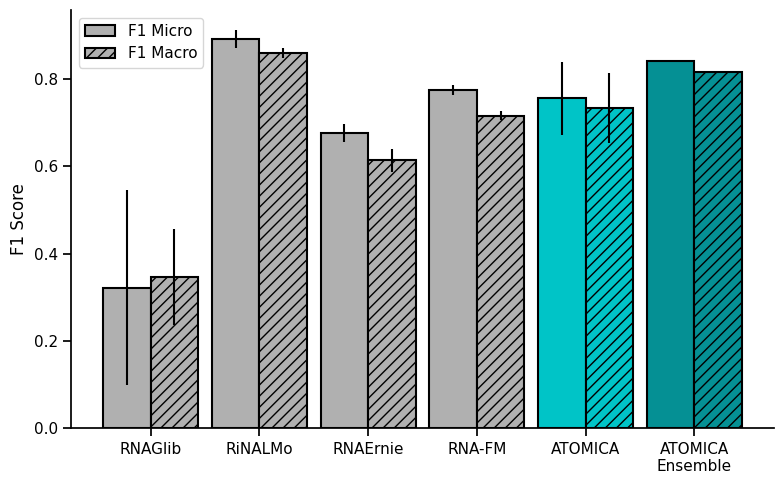

In [48]:
to_plot = pd.concat([
    rnaglib_baselines['RNAGo'],
    baseline_agg_results,
    all_metrics,
])
to_plot = to_plot.reset_index()
to_plot.rename(columns={'index': 'model'}, inplace=True)

# Prepare data for grouped bars
n_models = len(to_plot)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = to_plot[('f1_micro', 'mean')].values
f1_micro_stds = to_plot[('f1_micro', 'std')].values
f1_macro_means = to_plot[('f1_macro', 'mean')].values
f1_macro_stds = to_plot[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5)

# Customize the plot
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in to_plot['model']])
ax.legend(loc='best')
sns.despine()

plt.tight_layout()
plt.show()

In [32]:
test_metrics

,checkpoint_path,subset_accuracy,f1_macro,f1_micro,f1_weighted,split
0,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.880000,0.870058,0.903226,0.905798,atomica
1,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.693333,0.742286,0.733333,0.724438,atomica
2,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.613333,0.690116,0.694915,0.801766,atomica
3,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.666667,0.683810,0.716981,0.779635,atomica
4,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.720000,0.683054,0.732143,0.821224,atomica


In [33]:
val_metrics

,checkpoint_path,subset_accuracy,f1_macro,f1_micro,f1_weighted,split
0,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.893333,0.893730,0.929032,0.931483,atomica-val
1,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.906667,0.910061,0.940397,0.940122,atomica-val
2,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.893333,0.893449,0.935897,0.935455,atomica-val
3,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.920000,0.917812,0.934211,0.934933,atomica-val
4,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.933333,0.914861,0.954839,0.953298,atomica-val


# RNA Ligand

In [49]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Ligand/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines).reset_index(drop=True)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
baseline_agg_results

accuracy           balanced_accuracy            f1_macro  \
                    mean       std              mean       std      mean   
baseline_model                                                             
rinalmo         0.810606  0.026243          0.882375  0.025556  0.797815   
rnaernie        0.901515  0.112111          0.832567  0.194740  0.801715   
rnafm           0.901515  0.013122          0.942912  0.010925  0.904183   

                          f1_micro           f1_weighted            
                     std      mean       std        mean       std  
baseline_model                                                      
rinalmo         0.035177  0.810606  0.026243    0.819923  0.024574  
rnaernie        0.238956  0.901515  0.112111    0.891819  0.129720  
rnafm           0.014558  0.901515  0.013122    0.906021  0.011833

In [50]:
task_name = "RNA_Ligand"
for split in ["train", "val", "test"]:
    df = pd.read_parquet(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    label_counts = df['label'].value_counts()
    label_sample_probs = 1/label_counts
    print(split, label_counts, label_sample_probs/np.sum(label_sample_probs))

train label
1    137
0     46
2     20
Name: count, dtype: int64 label
1    0.092351
0    0.275045
2    0.632604
Name: count, dtype: float64
val label
1    29
0    10
2     4
Name: count, dtype: int64 label
1    0.089686
0    0.260090
2    0.650224
Name: count, dtype: float64
test label
1    29
0    10
2     5
Name: count, dtype: int64 label
1    0.103093
0    0.298969
2    0.597938
Name: count, dtype: float64


In [51]:
model_checkpoints = [
    f"{MODEL_DIR}/RNA_Ligand/models/version_82/checkpoint/epoch290_step11931.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_85/checkpoint/epoch337_step13858.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_86/checkpoint/epoch375_step15416.pt",
]

model_checkpoints = [
    # f"{MODEL_DIR}/RNA_Ligand/models/version_98/checkpoint/epoch406_step16687.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_99/checkpoint/epoch474_step19475.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_100/checkpoint/epoch575_step23616.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_102/checkpoint/epoch486_step19967.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_103/checkpoint/epoch368_step15129.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_104/checkpoint/epoch514_step21115.pt",
#     f"{MODEL_DIR}/RNA_Ligand/models/version_105/checkpoint/epoch395_step16236.pt",
#     f"{MODEL_DIR}/RNA_Ligand/models/version_106/checkpoint/epoch330_step13571.pt",
]


all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Ligand", split="test", sample_blocks=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results['label']),
        y_pred=np.stack(atomica_results['pred']),
        y_proba=np.stack(atomica_results['pred_probability']),
        labels=[0,1,2]
    )
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Ligand", split="test", sample_blocks=False)
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_pred=np.stack(atomica_results_val['pred']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        labels=[0,1,2]
    )
    if ensemble_prob is None:
        ensemble_prob = atomica_results_val['pred_probability']
    else:
        ensemble_prob += atomica_results_val['pred_probability']
    metrics_dict = {
        'model': 'atomica-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
    }
    all_metrics.append(metrics_dict)

ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_pred = np.argmax(ensemble_prob, axis=1)
ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(atomica_results['label']),
    y_pred=np.stack(ensemble_pred),
    y_proba=np.stack(ensemble_prob),
    labels=[0,1,2]
)
print(ensemble_metrics)

metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': ensemble_metrics.accuracy,
    'balanced_accuracy': ensemble_metrics.balanced_accuracy,
    'f1_macro': ensemble_metrics.f1_macro,
    'f1_micro': ensemble_metrics.f1_micro,
    'f1_weighted': ensemble_metrics.f1_weighted,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)

atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})

# for metric in ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_micro', 'f1_weighted']:
#     atomica_metrics.loc['atomica-ensemble', (metric, 'std')] = atomica_metrics.loc['atomica', (metric, 'std')] 

display(atomica_metrics)

MetricsResult(accuracy=0.9090909090909091, balanced_accuracy=0.9103448275862069, f1_macro=0.9103448275862069, f1_micro=0.9090909090909091, f1_weighted=0.9090909090909091, jaccard_macro=0.8458781362007168, jaccard_micro=0.8333333333333334, jaccard_weighted=0.8391984359726294, roc_auc_ovr_macro=0.9792540004507551, roc_auc_ovr_weighted=0.9729500891265598, roc_auc_ovo_macro=0.9862068965517242, roc_auc_ovo_weighted=0.9816614420062696, per_class={0: {'precision': 0.8, 'recall': 0.8, 'f1': 0.8, 'support': 10.0, 'jaccard': 0.6666666666666666}, 1: {'precision': 0.9310344827586207, 'recall': 0.9310344827586207, 'f1': 0.9310344827586207, 'support': 29.0, 'jaccard': 0.8709677419354839}, 2: {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 5.0, 'jaccard': 1.0}}, per_class_ovr_auc={0: 0.9676470588235294, 1: 0.9701149425287356, 2: 1.0})


accuracy           balanced_accuracy           f1_macro  \
                      mean       std              mean      std      mean   
model                                                                       
atomica           0.836364  0.043717          0.798851  0.10524  0.783094   
atomica-ensemble  0.909091       NaN          0.910345      NaN  0.910345   
atomica-val       0.836364  0.043717          0.798851  0.10524  0.783094   

                            f1_micro           f1_weighted            
                       std      mean       std        mean       std  
model                                                                 
atomica           0.086848  0.836364  0.043717    0.836672  0.045583  
atomica-ensemble       NaN  0.909091       NaN    0.909091       NaN  
atomica-val       0.086848  0.836364  0.043717    0.836672  0.045583

In [52]:
rnafm_preds = np.load(os.path.join(baselines['checkpoint_path'].iloc[3], "test_predictions.npy"))
y_true = np.stack(atomica_results['label'])
rnafm_tp = np.logical_and(y_true == rnafm_preds, y_true == 1)
atomica_tp = np.logical_and(y_true == ensemble_pred, y_true == 1)
np.sum(np.logical_and(rnafm_tp==False, atomica_tp)), len(y_true)

(4, 44)

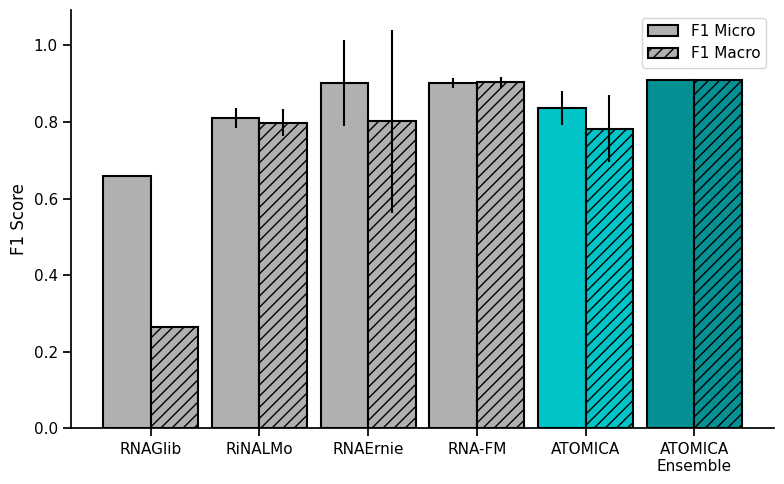

In [54]:
results = pd.concat([
    rnaglib_baselines['RNA_Ligand'],
    baseline_agg_results,
    atomica_metrics,
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[results['model'] != 'atomica-val']

# Prepare data for grouped bars
n_models = len(results)
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups (total width of each group including gap)

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics
f1_micro_means = results[('f1_micro', 'mean')].values
f1_micro_stds = results[('f1_micro', 'std')].values
f1_macro_means = results[('f1_macro', 'mean')].values
f1_macro_stds = results[('f1_macro', 'std')].values

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
bars1 = []
for i in range(n_models):
    bar = ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5, 
                 label='F1 Micro' if i == 0 else '')
    bars1.append(bar)

# f1_macro bars (right, with diagonal hatching)
bars2 = []
for i in range(n_models):
    bar = ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                 color=custom_colors[i], edgecolor='black', linewidth=1.5,
                 hatch='///', label='F1 Macro' if i == 0 else '')
    bars2.append(bar)

# Add error bars
ax.errorbar(x - width/2, f1_micro_means, yerr=f1_micro_stds,
            fmt='none', c='black', elinewidth=1.5)
ax.errorbar(x + width/2, f1_macro_means, yerr=f1_macro_stds,
            fmt='none', c='black', elinewidth=1.5)

# Customize the plot
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
ax.legend(loc='best')
sns.despine()

plt.tight_layout()
plt.show()

# RNA-Protein (SOTA)
This also beats RNAGlib 

In [55]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Protein/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results

accuracy           balanced_accuracy             roc_auc  \
                    mean       std              mean       std      mean   
baseline_model                                                             
rinalmo         0.690847  0.005113          0.551548  0.004303  0.629293   
rnaernie        0.707844  0.003394          0.562670  0.009848  0.637649   
rnafm           0.669357  0.011333          0.548803  0.011591  0.616460   

                             auprc            
                     std      mean       std  
baseline_model                                
rinalmo         0.004043  0.376287  0.002961  
rnaernie        0.002702  0.389490  0.006463  
rnafm           0.001187  0.356953  0.001894

In [56]:
model_checkpoints = [
    f"{MODEL_DIR}/RNA_Protein/models/version_1/checkpoint/epoch14_step3210.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_2/checkpoint/epoch12_step2782.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_3/checkpoint/epoch11_step2568.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_4/checkpoint/epoch14_step3210.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_5/checkpoint/epoch19_step4280.pt",
]

model_checkpoints_no_PRNA = [
    f"{MODEL_DIR}/RNA_Protein/models/version_6/checkpoint/epoch15_step3440.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_7/checkpoint/epoch9_step2140.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_8/checkpoint/epoch11_step2604.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_9/checkpoint/epoch13_step2982.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_10/checkpoint/epoch13_step3038.pt",
]

all_metrics = []
ensemble_prob = None
ensemble_prob_val = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Protein", split="test")
    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Protein", split="val")
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
        ensemble_prob_val = atomica_results_val['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
        ensemble_prob_val += atomica_results_val['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob_no_PRNA = None
for model_checkpoint in model_checkpoints_no_PRNA:
    atomica_results_no_PRNA = get_atomica_results(model_checkpoint, "RNA_Protein", split="test")
    if ensemble_prob_no_PRNA is None:
        ensemble_prob_no_PRNA = atomica_results_no_PRNA['pred_probability']
    else:
        ensemble_prob_no_PRNA += atomica_results_no_PRNA['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-PRNA',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_no_PRNA['label'] == atomica_results_no_PRNA['pred']),
        'roc_auc': roc_auc_score(atomica_results_no_PRNA['label'], atomica_results_no_PRNA['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_prob_no_PRNA = np.stack(ensemble_prob_no_PRNA) / len(model_checkpoints_no_PRNA)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results_val['label'], (ensemble_prob_val >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = ensemble_prob > best_f1
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

ensemble_pred_no_PRNA = ensemble_prob_no_PRNA > best_f1
precision, recall, thresholds = precision_recall_curve(atomica_results_no_PRNA['label'], ensemble_prob_no_PRNA)
auprc_no_PRNA = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble-no-PRNA',
    'checkpoint_path': 'ensemble-no-PRNA',
    'accuracy': np.mean(atomica_results_no_PRNA['label'] == ensemble_pred_no_PRNA),
    'roc_auc': roc_auc_score(atomica_results_no_PRNA['label'], ensemble_prob_no_PRNA),
    'auprc': auprc_no_PRNA,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

atomica_metrics.loc['atomica-ensemble', ('accuracy', 'std')] = atomica_metrics.loc['atomica', ('accuracy', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('roc_auc', 'std')] = atomica_metrics.loc['atomica', ('roc_auc', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('auprc', 'std')] = atomica_metrics.loc['atomica', ('auprc', 'std')] 
display(atomica_metrics)

accuracy             roc_auc               auprc  \
                              mean       std      mean       std      mean   
model                                                                        
atomica                   0.763672  0.003900  0.736803  0.011319  0.534873   
atomica-ensemble          0.725924  0.003900  0.764060  0.011319  0.590854   
atomica-ensemble-no-PRNA  0.725924       NaN  0.767663       NaN  0.607013   
atomica-no-PRNA           0.752391  0.024179  0.748712  0.007748  0.522441   

                                    
                               std  
model                               
atomica                   0.010648  
atomica-ensemble          0.010648  
atomica-ensemble-no-PRNA       NaN  
atomica-no-PRNA           0.000000

/tmp/ipykernel_1675703/2831287874.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)


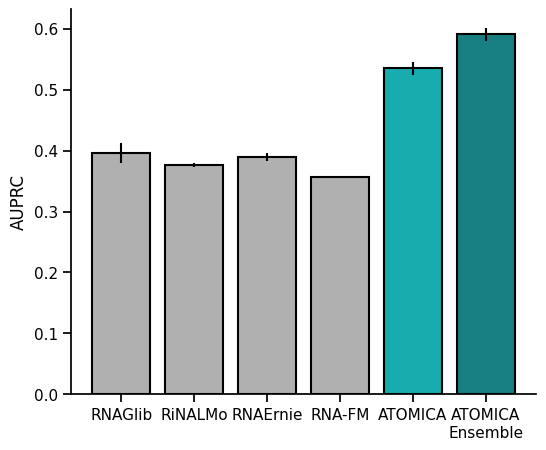

In [64]:
results = pd.concat([
    rnaglib_baselines['RNA_Protein'],
    baseline_agg_results,
    atomica_metrics,
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('PRNA'))]

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5
)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.show()

In [65]:
atomica_metrics

accuracy             roc_auc               auprc  \
                              mean       std      mean       std      mean   
model                                                                        
atomica                   0.763672  0.003900  0.736803  0.011319  0.534873   
atomica-ensemble          0.725924  0.003900  0.764060  0.011319  0.590854   
atomica-ensemble-no-PRNA  0.725924       NaN  0.767663       NaN  0.607013   
atomica-no-PRNA           0.752391  0.024179  0.748712  0.007748  0.522441   

                                    
                               std  
model                               
atomica                   0.010648  
atomica-ensemble          0.010648  
atomica-ensemble-no-PRNA       NaN  
atomica-no-PRNA           0.000000

In [68]:
results

accuracy             roc_auc               auprc  \
                              mean       std      mean       std      mean   
model                                                                        
atomica                   0.763672  0.003900  0.736803  0.011319  0.534873   
atomica-ensemble          0.725924  0.003900  0.764060  0.011319  0.590854   
atomica-ensemble-no-PRNA  0.725924       NaN  0.767663       NaN  0.607013   
atomica-no-PRNA           0.752391  0.024179  0.748712  0.007748  0.522441   

                                    
                               std  
model                               
atomica                   0.010648  
atomica-ensemble          0.010648  
atomica-ensemble-no-PRNA       NaN  
atomica-no-PRNA           0.000000

/tmp/ipykernel_1675703/457721900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)
/tmp/ipykernel_1675703/457721900.py:6: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)


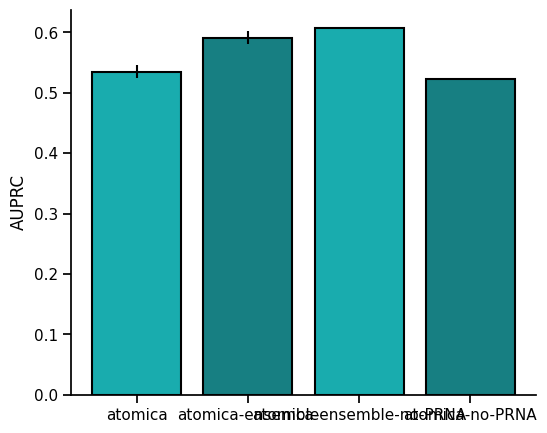

In [72]:
results = atomica_metrics.copy().reset_index()
results.rename(columns={'index': 'model'}, inplace=True)

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5
)

ax.set_xticks(x_positions)
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.show()

### Grouped scores by id

In [126]:
atomica_results['pred_bin'] = ensemble_pred >= best_t

atomica_results['correct'] = atomica_results['label'] == atomica_results['pred_bin']
balanced_acc = atomica_results.groupby('id')['correct'].mean().mean()

atomica_results['baseline_correct'] = atomica_results['label'] == 0
baseline_acc = atomica_results.groupby('id')['baseline_correct'].mean().mean()

print(balanced_acc, baseline_acc)

0.7491575746522185 0.6970169462442661


In [127]:
grouped = atomica_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.6130
Mean AUROC: 0.5501
Baseline: 0.4230


# RNA-Site (SOTA)




In [73]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Site/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results

accuracy           balanced_accuracy             roc_auc  \
                    mean       std              mean       std      mean   
baseline_model                                                             
rinalmo         0.922520  0.001412          0.511166  0.003046  0.673028   
rnaernie        0.922828  0.001223          0.508625  0.012465  0.597660   
rnafm           0.921904  0.000000          0.500000  0.000000  0.682820   

                             auprc            
                     std      mean       std  
baseline_model                                
rinalmo         0.015329  0.186942  0.020545  
rnaernie        0.018456  0.161948  0.016411  
rnafm           0.012065  0.136566  0.002877

In [74]:
# Ensemble five models with the highest validation AUPRC
model_checkpoints = [
    f"{MODEL_DIR}/RNA_Site/models/version_10/checkpoint/epoch51_step2444.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_28/checkpoint/epoch40_step1927.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_30/checkpoint/epoch67_step3128.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_32/checkpoint/epoch53_step2430.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_33/checkpoint/epoch53_step2592.pt",

    # f"{MODEL_DIR}/RNA_Site/models/version_29/checkpoint/epoch67_step3264.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_31/checkpoint/epoch73_step3478.pt",
]

model_checkpoints_no_RNAL = [
    f"{MODEL_DIR}/RNA_Site/models/version_34/checkpoint/epoch76_step3542.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_35/checkpoint/epoch62_step2961.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_37/checkpoint/epoch47_step2304.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_38/checkpoint/epoch46_step2115.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_39/checkpoint/epoch63_step3072.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_40/checkpoint/epoch73_step3404.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_41/checkpoint/epoch70_step3408.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_42/checkpoint/epoch45_step2070.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_43/checkpoint/epoch43_step2112.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_44/checkpoint/epoch67_step3128.pt",
    # f"{MODEL_DIR}/RNA_Site/models/version_45/checkpoint/epoch60_step2928.pt",
]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Site", split="test")
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val = get_atomica_results(model_checkpoint, "RNA_Site", split="val")
    precision, recall, thresholds = precision_recall_curve(atomica_results_val['label'], atomica_results_val['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_val['label'] == atomica_results_val['pred']),
        'roc_auc': roc_auc_score(atomica_results_val['label'], atomica_results_val['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob_no_RNAL = None
for model_checkpoint in model_checkpoints_no_RNAL:
    atomica_results_no_RNAL = get_atomica_results(model_checkpoint, "RNA_Site", split="test")
    if ensemble_prob_no_RNAL is None:
        ensemble_prob_no_RNAL = atomica_results_no_RNAL['pred_probability']
    else:
        ensemble_prob_no_RNAL += atomica_results_no_RNAL['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results_no_RNAL['label'], atomica_results_no_RNAL['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-RNAL',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_no_RNAL['label'] == atomica_results_no_RNAL['pred']),
        'roc_auc': roc_auc_score(atomica_results_no_RNAL['label'], atomica_results_no_RNAL['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

    atomica_results_val_no_RNAL = get_atomica_results(model_checkpoint, "RNA_Site", split="val")
    precision, recall, thresholds = precision_recall_curve(atomica_results_val_no_RNAL['label'], atomica_results_val_no_RNAL['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica-no-RNAL-val',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results_val_no_RNAL['label'] == atomica_results_val_no_RNAL['pred']),
        'roc_auc': roc_auc_score(atomica_results_val_no_RNAL['label'], atomica_results_val_no_RNAL['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)


ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_prob_no_RNAL = np.stack(ensemble_prob_no_RNAL) / len(model_checkpoints_no_RNAL)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results['label'], (ensemble_prob >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = (ensemble_prob > best_f1).astype(int)
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

ensemble_pred_no_RNAL = (ensemble_prob_no_RNAL > best_f1).astype(int)
precision, recall, thresholds = precision_recall_curve(atomica_results_no_RNAL['label'], ensemble_prob_no_RNAL)
auprc_no_RNAL = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble-no-RNAL',
    'checkpoint_path': 'ensemble-no-RNAL',
    'accuracy': np.mean(atomica_results_no_RNAL['label'] == ensemble_pred_no_RNAL),
    'roc_auc': roc_auc_score(atomica_results_no_RNAL['label'], ensemble_prob_no_RNAL),
    'auprc': auprc_no_RNAL,
}
all_metrics.append(metrics_dict)


all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

atomica_metrics.loc['atomica-ensemble', ('accuracy', 'std')] = atomica_metrics.loc['atomica', ('accuracy', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('roc_auc', 'std')] = atomica_metrics.loc['atomica', ('roc_auc', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('auprc', 'std')] = atomica_metrics.loc['atomica', ('auprc', 'std')] 
display(atomica_metrics)

accuracy             roc_auc               auprc  \
                              mean       std      mean       std      mean   
model                                                                        
atomica                   0.918333  0.007661  0.641742  0.036020  0.165894   
atomica-ensemble          0.923148  0.007661  0.697115  0.036020  0.236544   
atomica-ensemble-no-RNAL  0.922222       NaN  0.647174       NaN  0.186701   
atomica-no-RNAL           0.917963  0.008489  0.627846  0.030882  0.157305   
atomica-no-RNAL-val       0.919796  0.004551  0.694630  0.024978  0.243714   
atomica-val               0.920629  0.002689  0.689931  0.027720  0.220530   

                                    
                               std  
model                               
atomica                   0.038752  
atomica-ensemble          0.038752  
atomica-ensemble-no-RNAL       NaN  
atomica-no-RNAL           0.018142  
atomica-no-RNAL-val       0.018795  
atomica-val               0.031447

In [75]:
all_metrics[all_metrics['model'].isin(['atomica-no-RNAL-val'])].reset_index().sort_values(by='auprc', ascending=False)

,index,model,checkpoint_path,accuracy,roc_auc,auprc
4,19,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.731929,0.264634
2,15,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.692339,0.263789
3,17,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.702252,0.232881
0,11,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.911656,0.665179,0.228859
1,13,atomica-no-RNAL-val,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921832,0.681453,0.228406


In [76]:
all_metrics[all_metrics['model']=="atomica-no-RNAL"]

,model,checkpoint_path,accuracy,roc_auc,auprc
10,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.902778,0.639685,0.138010
12,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921759,0.642183,0.152589
14,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921759,0.665257,0.171472
16,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921759,0.591168,0.143887
18,atomica-no-RNAL,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,0.921759,0.600936,0.180569


/tmp/ipykernel_1675703/2334564788.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)


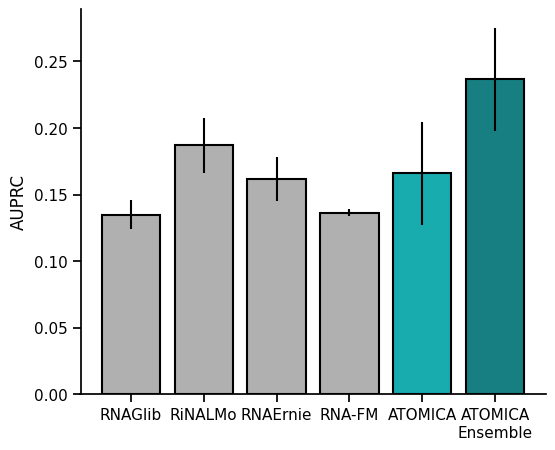

In [81]:
results = pd.concat([
    rnaglib_baselines['RNA_Site'],
    baseline_agg_results,
    atomica_metrics,
]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[(~results['model'].str.contains('RNAL')) & (~results['model'].str.contains('val'))]

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors, edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5
)

ax.set_xticks(x_positions)
ax.set_xticklabels([xtick_map[model] for model in results['model']])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.show()

/tmp/ipykernel_1675703/4291901644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)
/tmp/ipykernel_1675703/4291901644.py:6: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)


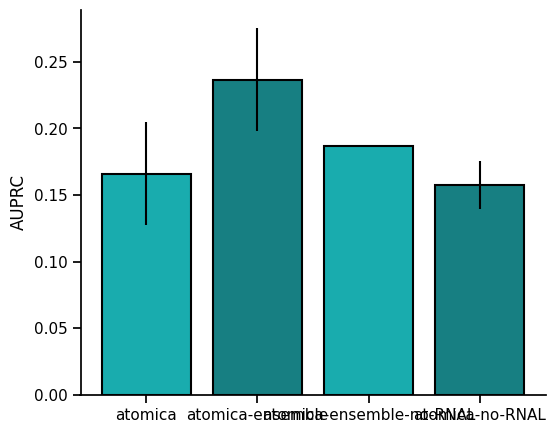

In [85]:
results = atomica_metrics[~atomica_metrics.index.str.contains('val')].copy().reset_index()
results.rename(columns={'index': 'model'}, inplace=True)

plt.figure(figsize=(6, 5))
# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, palette=custom_colors[-2:], edgecolor='black', linewidth=1.5,)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    elinewidth=1.5
)

ax.set_xticks(x_positions)
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.show()

### Grouped scores by id

In [95]:
ensemble_results = {
    'id': atomica_results['id'].apply(lambda x: "_".join(x.split('_')[0:2])),
    'pred': ensemble_pred,
    'label': atomica_results['label'],
    'pred_probability': ensemble_prob,
}
ensemble_results = pd.DataFrame(ensemble_results)
grouped = ensemble_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.5071
Mean AUROC: 0.5430
Baseline: 0.1034
